===== Input =====
m1 = 30.000 Msun
m2 = 30.000 Msun
f_orb = 20 Hz
DL = 10 kpc
|beta| = 0.1
beta_XYZ = [0.1 0.  0. ]

===== Lorentz / sky results =====
k = 0.92519046633
Theta' = 99.24506996 deg
Phi'   = 36.39680034 deg

===== First five samples =====
t=0.000000e+00 s, t'=0.000000e+00 s, h+=-1.997622e-17, hx=+0.000000e+00, H+'=-1.251581e-17, Hx'=+1.556932e-17
t=2.500000e-03 s, t'=2.312976e-03 s, h+=-1.616110e-17, hx=-9.393381e-18, H+'=-1.744664e-17, Hx'=+6.710555e-18
t=5.000000e-03 s, t'=4.625952e-03 s, h+=-6.172991e-18, hx=-1.519881e-17, H+'=-1.571344e-17, Hx'=-4.711412e-18
t=7.500000e-03 s, t'=6.938928e-03 s, h+=+6.172991e-18, hx=-1.519881e-17, H+'=-7.978243e-18, Hx'=-1.433378e-17
t=1.000000e-02 s, t'=9.251905e-03 s, h+=+1.616110e-17, hx=-9.393381e-18, H+'=+2.804373e-18, Hx'=-1.848113e-17

===== Numerical checks =====
max |Tr(h')| = 6.162975822039155e-33
max |h' . rhat'| = 2.5839061653313495e-33


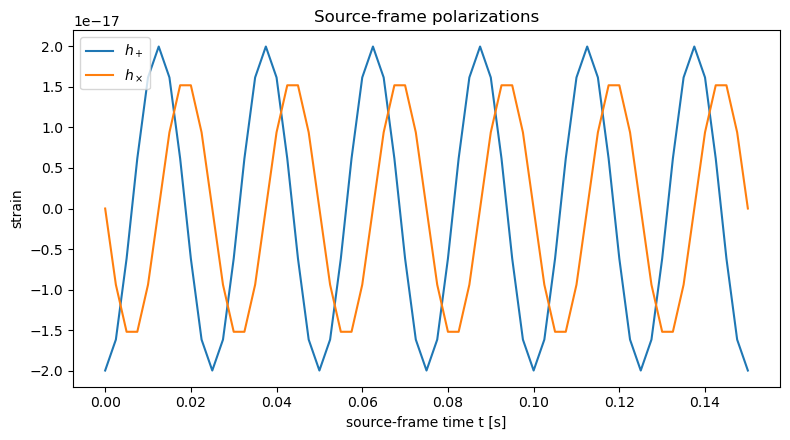

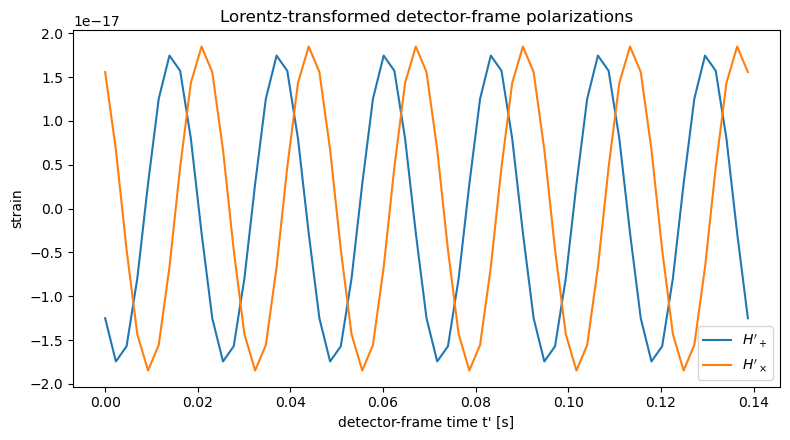

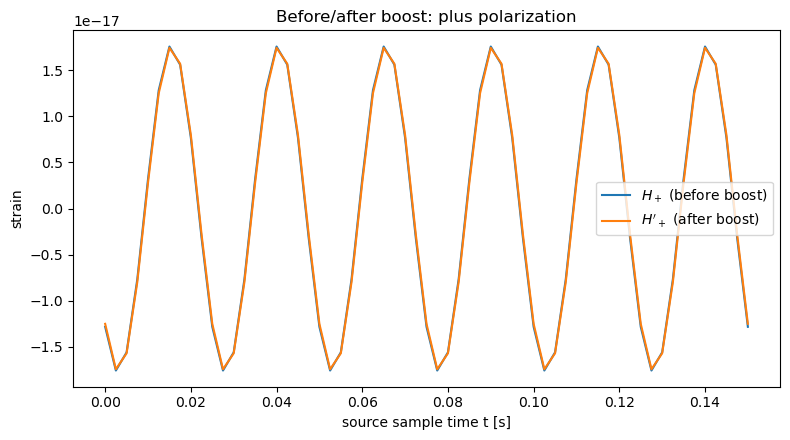

In [1]:
"""
lorentz_gw_polarization.py

From source-frame h_+(t), h_x(t) to detector-frame H'_+(t'), H'_x(t')
following He, Liu & Cao (2023), arXiv:2302.07532:
- 3D GW tensor decomposition: Eq. (50)
- exact Lorentz transformation of the 3D GW tensor: Eq. (59)
- aberration: Eq. (79)
- source/detector polarization-basis rotation: Eqs. (126)-(132)
- velocity-coordinate rotation: Eqs. (142)-(143)
- time redshift factor: Eqs. (121)-(122)

The first part also constructs a simple circular-binary h_+, h_x time series
from the quadrupole formula, matching the setup in the handwritten note.

All boost velocities are beta = v/c (dimensionless), as in the paper.
"""

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Physical constants (SI)
# ----------------------------
G = 6.67430e-11
C = 299_792_458.0
M_SUN = 1.98847e30
PC = 3.085677581491367e16
KPC = 1e3 * PC


# ============================================================
# 1. Geometry / polarization bases
# ============================================================

def spherical_triad(theta, phi):
    """
    Standard orthonormal spherical triad:
      rhat, thetahat, phihat
    for angles (theta, phi).
    """
    st, ct = np.sin(theta), np.cos(theta)
    sp, cp = np.sin(phi), np.cos(phi)

    rhat = np.array([st * cp, st * sp, ct], dtype=float)
    thetahat = np.array([ct * cp, ct * sp, -st], dtype=float)
    phihat = np.array([-sp, cp, 0.0], dtype=float)
    return rhat, thetahat, phihat


def polarization_tensors(theta, phi):
    """
    e^+_ij = theta_i theta_j - phi_i phi_j
    e^x_ij = theta_i phi_j + phi_i theta_j

    Returns:
      rhat, eplus, ecross
    """
    rhat, th, ph = spherical_triad(theta, phi)
    eplus = np.outer(th, th) - np.outer(ph, ph)
    ecross = np.outer(th, ph) + np.outer(ph, th)
    return rhat, eplus, ecross


def tensor_from_polarizations(hplus, hcross, eplus, ecross):
    """
    Build h_ij = h_+ e^+_ij + h_x e^x_ij.
    hplus/hcross can be scalars or 1D arrays.
    """
    hp = np.asarray(hplus)
    hx = np.asarray(hcross)
    if hp.ndim == 0:
        return hp * eplus + hx * ecross
    return hp[:, None, None] * eplus[None, :, :] + hx[:, None, None] * ecross[None, :, :]


def project_polarizations(hij, eplus, ecross):
    """
    Since e^+:e^+ = e^x:e^x = 2,
      h_+ = 1/2 h_ij e_+^{ij}
      h_x = 1/2 h_ij e_x^{ij}
    """
    h = np.asarray(hij)
    if h.ndim == 2:
        hp = 0.5 * np.einsum("ij,ij->", h, eplus)
        hx = 0.5 * np.einsum("ij,ij->", h, ecross)
    else:
        hp = 0.5 * np.einsum("tij,ij->t", h, eplus)
        hx = 0.5 * np.einsum("tij,ij->t", h, ecross)
    return hp, hx


# ============================================================
# 2. Circular-binary quadrupole waveform
# ============================================================

def circular_binary_quadrupole_ddot(t, m1_kg, m2_kg, omega_orb):
    """
    Circular binary in the x-y orbital plane, L || +z.

    n(t) = (cos(omega_orb t), sin(omega_orb t), 0)
    Q_ij = mu * a^2 * n_i n_j

    Uses Kepler:
      a = [G (m1+m2) / omega_orb^2]^(1/3)

    Returns Qddot_ij(t), shape (Nt,3,3).
    """
    M = m1_kg + m2_kg
    mu = m1_kg * m2_kg / M
    a = (G * M / omega_orb**2) ** (1.0 / 3.0)

    phase2 = 2.0 * omega_orb * np.asarray(t)
    amp = 2.0 * mu * a**2 * omega_orb**2

    Qdd = np.zeros((len(np.asarray(t)), 3, 3), dtype=float)
    Qdd[:, 0, 0] = -amp * np.cos(phase2)
    Qdd[:, 1, 1] = +amp * np.cos(phase2)
    Qdd[:, 0, 1] = -amp * np.sin(phase2)
    Qdd[:, 1, 0] = Qdd[:, 0, 1]
    return Qdd


def source_waveform_from_quadrupole(t, m1_kg, m2_kg, omega_orb, DL_m, iota):
    """
    Handwritten-note setup:
      h_ij = (2G / (DL c^4)) Qddot_ij

    The raw quadrupole tensor is then projected onto the transverse
    +/x basis for GW propagation toward the detector.

    We choose source coordinates exactly as in the paper's waveform convention:
      z || orbital angular momentum L
      detector lies in the x-z plane
      propagation direction rhat = (sin iota, 0, cos iota)
      i.e. (theta, phi) = (iota, 0)
    """
    Qdd = circular_binary_quadrupole_ddot(t, m1_kg, m2_kg, omega_orb)
    hij_raw = (2.0 * G / (DL_m * C**4)) * Qdd

    rhat, eplus, ecross = polarization_tensors(iota, 0.0)
    hplus, hcross = project_polarizations(hij_raw, eplus, ecross)

    # Rebuild the physical TT tensor from its two polarizations.
    hij_tt = tensor_from_polarizations(hplus, hcross, eplus, ecross)
    return hplus, hcross, hij_tt, rhat


# ============================================================
# 3. Lorentz boost of GW tensor: paper Eq. (59)
# ============================================================

def gamma_from_beta(beta):
    beta = np.asarray(beta, dtype=float)
    b2 = float(np.dot(beta, beta))
    if b2 >= 1.0:
        raise ValueError("|beta| must be < 1.")
    return 1.0 / np.sqrt(1.0 - b2)


def aberrate_direction(rhat, beta):
    """
    Exact aberration formula, paper Eq. (79).

    rhat : original GW propagation direction
    beta : boost velocity v/c in the same Cartesian basis
    """
    rhat = np.asarray(rhat, dtype=float)
    beta = np.asarray(beta, dtype=float)
    b = np.linalg.norm(beta)

    if b < 1e-15:
        return rhat.copy()

    gamma = gamma_from_beta(beta)
    vhat = beta / b
    rv = float(np.dot(rhat, beta))
    rvhat = float(np.dot(rhat, vhat))
    den = 1.0 - rv

    rprime = ((rvhat - b) / den) * vhat \
             + (rhat - rvhat * vhat) / (gamma * den)

    # numerical cleanup
    rprime /= np.linalg.norm(rprime)
    return rprime


def lorentz_transform_gw_tensor(hij, rhat, beta):
    """
    Exact 3D GW tensor Lorentz transformation, paper Eq. (59).

    hij can be shape (3,3) or (Nt,3,3).
    rhat is the GW propagation direction.
    beta = v/c.

    Returns h'_ij with same shape as hij.
    """
    h = np.asarray(hij, dtype=float)
    r = np.asarray(rhat, dtype=float)
    v = np.asarray(beta, dtype=float)

    gamma = gamma_from_beta(v)
    rv = float(np.dot(r, v))
    den = 1.0 - rv

    if abs(den) < 1e-14:
        raise ValueError("1 - rhat·beta is too close to zero.")

    a = gamma / (1.0 + gamma)
    bvec = r - a * v

    bracket = (
        np.outer(r, r)
        - a * (np.outer(r, v) + np.outer(v, r))
        + a**2 * np.outer(v, v)
    )

    if h.ndim == 2:
        hv = h @ v
        vhv = float(v @ h @ v)
        return (
            h
            + (vhv / den**2) * bracket
            + np.outer(bvec, hv) / den
            + np.outer(hv, bvec) / den
        )

    hv = np.einsum("tij,j->ti", h, v)
    vhv = np.einsum("i,tij,j->t", v, h, v)

    return (
        h
        + (vhv / den**2)[:, None, None] * bracket[None, :, :]
        + np.einsum("i,tj->tij", bvec, hv) / den
        + np.einsum("ti,j->tij", hv, bvec) / den
    )


# ============================================================
# 4. Coordinate rotation between (X,Y,Z) and (x,y,z)
#    paper Eqs. (142)-(143)
# ============================================================

def beta_XYZ_to_xyz(beta_XYZ, Theta, Phi, iota):
    """
    Paper Eq. (143).

    (X,Y,Z): detector-origin Cartesian basis in source frame
    (x,y,z): BBH waveform/source basis, with z || orbital angular momentum
    """
    d = iota - Theta
    cP, sP = np.cos(Phi), np.sin(Phi)
    cd, sd = np.cos(d), np.sin(d)

    R = np.array([
        [ cP,          sP,       0.0],
        [-sP * cd,     cP * cd,  sd ],
        [ sP * sd,    -cP * sd,  cd ],
    ])
    return R @ np.asarray(beta_XYZ, dtype=float)


def beta_xyz_to_XYZ(beta_xyz, Theta, Phi, iota):
    """
    Inverse of Eq. (143), equivalent to paper Eq. (147).
    """
    d = iota - Theta
    cP, sP = np.cos(Phi), np.sin(Phi)
    cd, sd = np.cos(d), np.sin(d)

    Rinv = np.array([
        [cP, -sP * cd,  sP * sd],
        [sP,  cP * cd, -cP * sd],
        [0.0,      sd,       cd ],
    ])
    return Rinv @ np.asarray(beta_xyz, dtype=float)


# ============================================================
# 5. Convert h_+,h_x to H'_+,H'_x
# ============================================================

def source_h_to_detector_Hprime(
    hplus,
    hcross,
    iota,
    Theta,
    Phi,
    Psi,
    beta_XYZ,
):
    """
    Main function requested:

      input:
        hplus(t), hcross(t)       : source waveform basis
        iota                      : BBH inclination
        Theta, Phi                : source sky localization
        Psi                       : polarization angle
        beta_XYZ=(vX,vY,vZ)/c     : source velocity relative to detector

      output:
        Hplus_prime(t'), Hcross_prime(t')
        plus useful intermediate quantities.

    Strategy:
      1) Eqs. (129)-(130): h_+,h_x -> H_+,H_x in the detector sky basis.
      2) Build h_ij = H_+ E^+_ij + H_x E^x_ij.
      3) GW propagation direction in this basis is rhat = -Rhat.
      4) Apply exact tensor boost Eq. (59).
      5) Aberrate propagation direction with Eq. (79), so Rhat'=-rhat'.
      6) Build new sky basis E'^+,E'^x and project h'_ij.
    """
    hp = np.asarray(hplus, dtype=float)
    hx = np.asarray(hcross, dtype=float)
    beta_XYZ = np.asarray(beta_XYZ, dtype=float)

    # Eqs. (129)-(130)
    c2, s2 = np.cos(2.0 * Psi), np.sin(2.0 * Psi)
    Hplus = hp * c2 + hx * s2
    Hcross = hx * c2 - hp * s2

    # Source position from detector: Rhat(Theta,Phi)
    Rhat, Eplus, Ecross = polarization_tensors(Theta, Phi)

    # GW propagates from source to detector, i.e. -Rhat
    rprop = -Rhat

    # Build tensor in uppercase basis and boost it
    Hij = tensor_from_polarizations(Hplus, Hcross, Eplus, Ecross)
    Hij_prime = lorentz_transform_gw_tensor(Hij, rprop, beta_XYZ)

    # Aberrated direction and new source sky direction
    rprop_prime = aberrate_direction(rprop, beta_XYZ)
    Rhat_prime = -rprop_prime

    # Convert Rhat' to (Theta',Phi') robustly
    z = np.clip(Rhat_prime[2], -1.0, 1.0)
    Theta_prime = np.arccos(z)
    Phi_prime = np.mod(np.arctan2(Rhat_prime[1], Rhat_prime[0]), 2.0 * np.pi)

    _, Eplus_prime, Ecross_prime = polarization_tensors(Theta_prime, Phi_prime)
    Hplus_prime, Hcross_prime = project_polarizations(
        Hij_prime, Eplus_prime, Ecross_prime
    )

    # Eq. (122), with rhat = propagation direction = -Rhat
    gamma = gamma_from_beta(beta_XYZ)
    k = 1.0 / (gamma * (1.0 - np.dot(beta_XYZ, rprop)))

    return {
        "Hplus": Hplus,
        "Hcross": Hcross,
        "Hplus_prime": Hplus_prime,
        "Hcross_prime": Hcross_prime,
        "Theta_prime": Theta_prime,
        "Phi_prime": Phi_prime,
        "k": k,
        "Hij": Hij,
        "Hij_prime": Hij_prime,
        "Rhat_prime": Rhat_prime,
    }


# ============================================================
# 6. Optional paper phase lambda, useful as a cross-check
# ============================================================

def lambda_from_tensor_method(theta, phi, beta):
    """
    Compute lambda(theta,phi,beta) using the paper's exact tensor method,
    equivalent to Eqs. (110)-(113), rather than hard-coding Eq. (114).

    Set h_+=1, h_x=0, boost the tensor, project on the aberrated basis:
      e^{-2 i lambda} = h'_+ - i h'_x

    Returns lambda in radians, modulo pi.
    """
    r, ep, ex = polarization_tensors(theta, phi)
    h_test = ep.copy()  # h_+=1, h_x=0

    h_test_prime = lorentz_transform_gw_tensor(h_test, r, beta)
    rprime = aberrate_direction(r, beta)

    thp = np.arccos(np.clip(rprime[2], -1.0, 1.0))
    php = np.arctan2(rprime[1], rprime[0])
    _, epp, exp = polarization_tensors(thp, php)

    hp_p, hx_p = project_polarizations(h_test_prime, epp, exp)
    z = hp_p - 1j * hx_p

    # normalize tiny numerical drift from |z|=1
    z /= abs(z)
    lam = -0.5 * np.angle(z)
    return lam


# ============================================================
# 7. Full numerical example
# ============================================================

def run_demo():
    # --------------------------------------------------------
    # Replace these demo values by the exact values
    # --------------------------------------------------------
    m1 = 30.0 * M_SUN
    m2 = 30.0 * M_SUN

    # Orbital frequency; GW quadrupole frequency is ~2 f_orb
    f_orb = 20.0               # Hz (DEMO VALUE)
    omega_orb = 2.0 * np.pi * f_orb

    # Handwritten note: DL = 10 kpc or 1 kpc
    DL = 10.0 * KPC

    # Geometry (DEMO VALUES; replace if assigned)
    iota = np.deg2rad(60.0)
    Theta = np.deg2rad(100.0)
    Phi = np.deg2rad(40.0)
    Psi = np.deg2rad(25.0)

    # |v| ~ 0.1c or 0.3c.
    # A DIRECTION is also required. Here we use +X as a demo.
    beta_mag = 0.1
    beta_direction_XYZ = np.array([1.0, 0.0, 0.0])
    beta_XYZ = beta_mag * beta_direction_XYZ / np.linalg.norm(beta_direction_XYZ)

    # simulate about 3 orbital periods.
    T_orb = 2.0 * np.pi / omega_orb

    # dt ~ O(0.1) * 2pi/omega_orb.
    # 0.05 T_orb gives 20 samples/orbit; use smaller if desired.
    dt = 0.05 * T_orb
    t = np.arange(0.0, 3.0 * T_orb + 0.5 * dt, dt)

    # ---- h_+, h_x from circular quadrupole
    hplus, hcross, hij_source, rhat_source = source_waveform_from_quadrupole(
        t=t,
        m1_kg=m1,
        m2_kg=m2,
        omega_orb=omega_orb,
        DL_m=DL,
        iota=iota,
    )

    # ---- requested H'_+, H'_x
    out = source_h_to_detector_Hprime(
        hplus=hplus,
        hcross=hcross,
        iota=iota,
        Theta=Theta,
        Phi=Phi,
        Psi=Psi,
        beta_XYZ=beta_XYZ,
    )

    # For constant velocity, paper Eq. (121): t' = k t
    t_prime = out["k"] * t

    print("===== Input =====")
    print(f"m1 = {m1/M_SUN:.3f} Msun")
    print(f"m2 = {m2/M_SUN:.3f} Msun")
    print(f"f_orb = {f_orb:.6g} Hz")
    print(f"DL = {DL/KPC:.6g} kpc")
    print(f"|beta| = {np.linalg.norm(beta_XYZ):.6g}")
    print(f"beta_XYZ = {beta_XYZ}")
    print()
    print("===== Lorentz / sky results =====")
    print(f"k = {out['k']:.12g}")
    print(f"Theta' = {np.rad2deg(out['Theta_prime']):.8f} deg")
    print(f"Phi'   = {np.rad2deg(out['Phi_prime']):.8f} deg")
    print()
    print("===== First five samples =====")
    for j in range(min(5, len(t))):
        print(
            f"t={t[j]:.6e} s, t'={t_prime[j]:.6e} s, "
            f"h+={hplus[j]:+.6e}, hx={hcross[j]:+.6e}, "
            f"H+'={out['Hplus_prime'][j]:+.6e}, "
            f"Hx'={out['Hcross_prime'][j]:+.6e}"
        )

    # ---- Basic TT checks on boosted tensor
    trace = np.trace(out["Hij_prime"], axis1=1, axis2=2)
    rprop_prime = -out["Rhat_prime"]
    trans = np.einsum("tij,j->ti", out["Hij_prime"], rprop_prime)

    print()
    print("===== Numerical checks =====")
    print("max |Tr(h')| =", np.max(np.abs(trace)))
    print("max |h' . rhat'| =", np.max(np.linalg.norm(trans, axis=1)))

    # ---- Plot 1: source h+,hx
    plt.figure(figsize=(8, 4.5))
    plt.plot(t, hplus, label=r"$h_+$")
    plt.plot(t, hcross, label=r"$h_\times$")
    plt.xlabel("source-frame time t [s]")
    plt.ylabel("strain")
    plt.title("Source-frame polarizations")
    plt.legend()
    plt.tight_layout()

    # ---- Plot 2: detector H'+,H'x
    plt.figure(figsize=(8, 4.5))
    plt.plot(t_prime, out["Hplus_prime"], label=r"$H'_+$")
    plt.plot(t_prime, out["Hcross_prime"], label=r"$H'_\times$")
    plt.xlabel("detector-frame time t' [s]")
    plt.ylabel("strain")
    plt.title("Lorentz-transformed detector-frame polarizations")
    plt.legend()
    plt.tight_layout()

    # ---- Plot 3: direct comparison on sample index
    plt.figure(figsize=(8, 4.5))
    plt.plot(t, out["Hplus"], label=r"$H_+$ (before boost)")
    plt.plot(t, out["Hplus_prime"], label=r"$H'_+$ (after boost)")
    plt.xlabel("source sample time t [s]")
    plt.ylabel("strain")
    plt.title("Before/after boost: plus polarization")
    plt.legend()
    plt.tight_layout()

    plt.show()

    return t, t_prime, hplus, hcross, out


if __name__ == "__main__":
    run_demo()